In [12]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
MODEL_CHECKPOINT = MODEL_DIR + "best_model.pth"
MODEL_HISTORY = np.load(MODEL_DIR + "history.npy", allow_pickle=True).item()
BATCH_SIZE = 64
STEP_FOR_RANK_SWEP_EVAL = 1

In [13]:
# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    pin_memory = True
    num_workers = 16
    print("Using CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    pin_memory = False
    num_workers = 0
    print("Using MPS")
else:
    device = torch.device("cpu")
    pin_memory = False
    print("Using CPU")

Using MPS


In [14]:
base_model = KWSBase(cfg).to(device)
base_model.load_state_dict(torch.load(MODEL_CHECKPOINT, map_location=device))

# print the model architecture and number of parameters
n_total = sum(p.numel() for p in base_model.parameters())
print(f"Base model parameters: {n_total}")


Base model parameters: 338718


In [15]:
#Datasets and dataloaders
data_dir = get_data_dir()
train_set = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True, **noise_train_cfg.model_dump())
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, pin_memory = pin_memory, num_workers=num_workers)

val_set = SpeechCommandsGoogle(root=str(data_dir), subset="validation", download=True, **noise_eval_cfg.model_dump())
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, pin_memory = pin_memory, num_workers=num_workers)

Adding noise: 100%|██████████| 4515/4515 [00:14<00:00, 311.58sample/s]


In [16]:
def validate_model(
    model: nn.Module,
    val_loader,
    criterion: nn.Module,
    device: torch.device,
    snr_values=None,
    verbose: bool = True,
    fixed_rank: Optional[int] = None,
) -> Tuple[
    Dict[Union[int, float, None], Dict[str, float]],
    List[Dict[str, Any]],
]:
    """
    Evaluate `model` on the validation set for different SNR values.

    Assumes:
        - val_loader.dataset._set_snr(snr) exists.
        - val_loader yields (waveforms, labels, meta).

    Returns:
        results:
            dict {snr: {"loss": float, "acc": float}}

        per_sample_records:
            list of dicts, one per sample, containing:
              - snr
              - rank
              - pred
              - target
              - correct
              - optional metadata fields if present:
                    label, utterance, noise_type, snr
    """
    if snr_values is None:
        snr_values = [None]

    model.eval()
    results: Dict[Union[int, float, None], Dict[str, float]] = {}
    per_sample_records: List[Dict[str, Any]] = []

    ds = val_loader.dataset

    def _get_meta_item(meta_val, i):
        if isinstance(meta_val, (list, tuple)):
            return meta_val[i]
        if torch.is_tensor(meta_val):
            v = meta_val[i]
            return v.item() if v.numel() == 1 else v.detach().cpu()
        return meta_val

    with torch.no_grad():
        for snr in snr_values:
            ds._set_snr(snr)

            total_loss = 0.0
            total_correct = 0
            total_samples = 0

            pbar = tqdm(val_loader, desc=f"SNR={snr}", leave=False)

            for waveforms, labels, meta in pbar:
                waveforms = waveforms.to(device)
                labels = labels.to(device)

                logits = model(waveforms, ranks=fixed_rank)
                loss = criterion(logits, labels)

                batch_size = labels.size(0)
                total_samples += batch_size
                total_loss += loss.item() * batch_size

                preds = logits.argmax(dim=1)
                correct_mask = preds == labels
                total_correct += int(correct_mask.sum().item())

                preds_cpu = preds.detach().cpu().tolist()
                labels_cpu = labels.detach().cpu().tolist()
                correct_cpu = correct_mask.detach().cpu().tolist()

                for i in range(batch_size):
                    rec = {
                        "snr_eval": snr, 
                        "rank": fixed_rank,
                        "pred": int(preds_cpu[i]),
                        "target": int(labels_cpu[i]),
                        "correct": bool(correct_cpu[i]),
                    }

                    if isinstance(meta, dict):
                        for k in ["label", "utterance", "noise_type"]:
                            if k in meta:
                                rec[k] = _get_meta_item(meta[k], i)
                        if "snr" in meta:
                             rec["snr_sample"] = _get_meta_item(meta["snr"], i)

                    per_sample_records.append(rec)

                pbar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    acc=f"{100 * total_correct / total_samples:.2f}%",
                )

            avg_loss = total_loss / total_samples
            avg_acc = 100.0 * total_correct / total_samples
            results[snr] = {"loss": avg_loss, "acc": avg_acc}

            if verbose:
                print(f"SNR={snr}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

    return results, per_sample_records


In [17]:
VAL_SNR_VALUES = [-5, 0, 5, 10,15,float('inf')]
# deactivate low-rank everywhere
base_model.toggle_low_rank((False,False,False))
#full_rank_acc = validate_model(base_model, val_loader, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=None)
results, per_sample_records = validate_model(base_model, val_loader, nn.CrossEntropyLoss(), device, snr_values=VAL_SNR_VALUES, verbose=False, fixed_rank=None)
print(f"\n=== Full Rank Val Accuracy per SNR ===")
for snr, stats in results.items():
    print(f"  SNR={str(snr):>6}: acc={stats['acc']:.2f}%  loss={stats['loss']:.4f}")
print("-" * 60)


=== Full Rank Val Accuracy per SNR ===
  SNR=    -5: acc=79.73%  loss=0.5906
  SNR=     0: acc=87.91%  loss=0.3598
  SNR=     5: acc=91.27%  loss=0.2692
  SNR=    10: acc=92.96%  loss=0.2269
  SNR=    15: acc=93.64%  loss=0.2058
  SNR=   inf: acc=95.22%  loss=0.1841
------------------------------------------------------------


In [18]:
def evaluate_rank_sweep(
    model: nn.Module,
    validate_fn,
    val_loader,
    criterion: nn.Module,
    device: torch.device,
    *,
    max_rank: int,
    snr_values,
    step: int = 4,
    stop_at_half_rank: bool = False,
    verbose: bool = True,
) -> tuple[
    Dict[str, Dict[Union[int, float, None], Dict[str, float]]],
    pd.DataFrame,
]:
    """
    Sweep fixed ranks and evaluate the model.

    Assumes validate_fn returns:
        results, per_sample_records

    Returns:
        results_by_rank:
            dict mapping "rank_{r}" -> {snr: {"loss": float, "acc": float}}

        per_sample_df:
            long-format DataFrame with columns:
              - snr
              - rank
              - pred
              - target
              - correct
              - optional metadata (label, utterance, noise_type)
    """

    results_by_rank: Dict[str, Dict[Union[int, float, None], Dict[str, float]]] = {}
    all_sample_records: List[Dict[str, Any]] = []

    for rank in range(step, max_rank + 1, step):
        if stop_at_half_rank and rank > (max_rank // 2):
            if verbose:
                print(
                    f"Stopping sweep at rank {rank} "
                    f"(stop_at_half_rank=True, max_rank={max_rank})"
                )
            break

        results, per_sample_records = validate_fn(
            model,
            val_loader,
            criterion,
            device,
            snr_values=snr_values,
            verbose=False,
            fixed_rank=rank,
        )

        results_by_rank[f"rank_{rank}"] = results
        all_sample_records.extend(per_sample_records)

        if verbose:
            print(f"\n=== Rank {rank} Validation ===")
            for snr, stats in results.items():
                print(
                    f"  SNR={str(snr):>6}: "
                    f"acc={stats['acc']:.2f}%  "
                    f"loss={stats['loss']:.4f}"
                )
            print("-" * 60)

    per_sample_df = pd.DataFrame(all_sample_records)

    return results_by_rank, per_sample_df


In [19]:
# Define combinations declaratively (good!)
combs = {
    "comb_1": {
        "stacks_low_rank": [True, True, True],
        "frontend_low_rank": False,
    },
    # "comb_2": {
    #     "stacks_low_rank": [True, True, False],
    #     "frontend_low_rank": False,
    # },
    # "comb_3": {
    #     "stacks_low_rank": [True, False, False],
    #     "frontend_low_rank": False,
    # },
}

all_results = {}
all_per_sample_dfs = {}
criterion = nn.CrossEntropyLoss()

for comb_name, cfg in combs.items():
    print(f"\n=== Testing combination: {comb_name} ===")
    print(f"    stacks_low_rank={cfg['stacks_low_rank']}, "
          f"frontend_low_rank={cfg['frontend_low_rank']}")

    # Toggle low-rank according to config
    base_model.toggle_low_rank(
        cfg["stacks_low_rank"],
        low_rank_frontend=cfg["frontend_low_rank"],
    )

    sweep_results, comb_1_df = evaluate_rank_sweep(
        base_model,
        validate_model,
        val_loader,
        criterion,
        device,
        max_rank=128,
        snr_values=VAL_SNR_VALUES,
        step=STEP_FOR_RANK_SWEP_EVAL,
        stop_at_half_rank=True,
        verbose=True,
    )

    all_results[comb_name] = {
        "config": cfg,
        "sweep": sweep_results,
    }
    
    # Save per-sample df for this combination
    comb_1_df.to_csv(MODEL_DIR + f"per_sample_results_{comb_name}.csv", index=False)
    all_per_sample_dfs[comb_name] = comb_1_df

# Save the aggregated results to model directory
with open(MODEL_DIR + "low_rank_sweep_results.json", "w") as f:
    json.dump(all_results, f, indent=4)

print(f"\nResults saved to {MODEL_DIR}")
for comb_name, df in all_per_sample_dfs.items():
    print(f"  {comb_name}: DataFrame shape = {df.shape}, Columns = {list(df.columns)}")


=== Testing combination: comb_1 ===
    stacks_low_rank=[True, True, True], frontend_low_rank=False



=== Rank 1 Validation ===
  SNR=    -5: acc=11.43%  loss=3.2506
  SNR=     0: acc=11.45%  loss=3.2162
  SNR=     5: acc=11.65%  loss=3.2049
  SNR=    10: acc=11.89%  loss=3.2166
  SNR=    15: acc=12.18%  loss=3.2499
  SNR=   inf: acc=12.12%  loss=4.0915
------------------------------------------------------------



=== Rank 2 Validation ===
  SNR=    -5: acc=10.99%  loss=3.8943
  SNR=     0: acc=11.27%  loss=3.8741
  SNR=     5: acc=11.47%  loss=3.8892
  SNR=    10: acc=11.67%  loss=3.9465
  SNR=    15: acc=11.45%  loss=4.0445
  SNR=   inf: acc=10.43%  loss=5.5669
------------------------------------------------------------



=== Rank 3 Validation ===
  SNR=    -5: acc=9.75%  loss=3.9395
  SNR=     0: acc=10.83%  loss=3.8804
  SNR=     5: acc=11.89%  loss=3.8248
  SNR=    10: acc=13.20%  loss=3.7915
  SNR=    15: acc=14.13%  loss=3.7876
  SNR=   inf: acc=13.89%  loss=4.6274
------------------------------------------------------------



=== Rank 4 Validation ===
  SNR=    -5: acc=11.18%  loss=3.8821
  SNR=     0: acc=12.00%  loss=3.7386
  SNR=     5: acc=13.18%  loss=3.6017
  SNR=    10: acc=14.02%  loss=3.5004
  SNR=    15: acc=14.26%  loss=3.4491
  SNR=   inf: acc=15.55%  loss=4.0946
------------------------------------------------------------


...


=== Rank 60 Validation ===
  SNR=    -5: acc=79.73%  loss=0.5973
  SNR=     0: acc=87.66%  loss=0.3634
  SNR=     5: acc=91.14%  loss=0.2721
  SNR=    10: acc=92.89%  loss=0.2298
  SNR=    15: acc=93.51%  loss=0.2080
  SNR=   inf: acc=95.02%  loss=0.1884
------------------------------------------------------------



=== Rank 61 Validation ===
  SNR=    -5: acc=79.80%  loss=0.5966
  SNR=     0: acc=87.80%  loss=0.3627
  SNR=     5: acc=91.12%  loss=0.2716
  SNR=    10: acc=92.93%  loss=0.2290
  SNR=    15: acc=93.51%  loss=0.2069
  SNR=   inf: acc=95.02%  loss=0.1876
------------------------------------------------------------



=== Rank 62 Validation ===
  SNR=    -5: acc=79.87%  loss=0.5967
  SNR=     0: acc=87.71%  loss=0.3628
  SNR=     5: acc=91.21%  loss=0.2717
  SNR=    10: acc=92.87%  loss=0.2293
  SNR=    15: acc=93.51%  loss=0.2072
  SNR=   inf: acc=95.02%  loss=0.1873
------------------------------------------------------------



=== Rank 63 Validation ===
  SNR=    -5: acc=79.78%  loss=0.5961
  SNR=     0: acc=87.69%  loss=0.3626
  SNR=     5: acc=91.23%  loss=0.2718
  SNR=    10: acc=92.96%  loss=0.2291
  SNR=    15: acc=93.58%  loss=0.2070
  SNR=   inf: acc=94.99%  loss=0.1870
------------------------------------------------------------



=== Rank 64 Validation ===
  SNR=    -5: acc=79.84%  loss=0.5956
  SNR=     0: acc=87.69%  loss=0.3622
  SNR=     5: acc=91.25%  loss=0.2715
  SNR=    10: acc=93.00%  loss=0.2287
  SNR=    15: acc=93.55%  loss=0.2065
  SNR=   inf: acc=95.08%  loss=0.1861
------------------------------------------------------------
Stopping sweep at rank 65 (stop_at_half_rank=True, max_rank=128)

Results saved to /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/
  comb_1: DataFrame shape = (1733760, 9), Columns = ['snr_eval', 'rank', 'pred', 'target', 'correct', 'label', 'utterance', 'noise_type', 'snr_sample']


### Analysis of results for combination 1

In [32]:
comb_1_df = all_per_sample_dfs["comb_1"]

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rank_vs_acc_per_snr(
    df: pd.DataFrame,
    *,
    include_silence: bool = True,
    y_mode: str = "acc",                 # "acc" or "ratio"
    ratio_target: float = 0.8,           # only used when y_mode="ratio"
    plot_per_snr: bool = True,           # NEW: toggle individual SNR plots
    silence_label: str = "SILENCE",
    label_col: str = "label",
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    figsize_all=(7, 5),
    figsize_single=(6, 4),
    marker="o",
    print_ratio_summary: bool = True,
):
    """
    Plots:
      1) One plot with ALL SNR curves together (always)
      2) Optionally (plot_per_snr=True) one plot per SNR

    y_mode:
      - "acc"   : accuracy in %
      - "ratio" : accuracy / max_accuracy_per_SNR

    When y_mode="ratio", optionally prints and returns a summary table with
    the minimum rank needed to reach `ratio_target` for each SNR.

    Returns
    -------
    summary : pd.DataFrame
        MultiIndex (rank, snr_eval) with columns:
        [acc_all, acc_non_silence, acc_diff, acc_ratio]
    ratio_rank_summary : pd.DataFrame or None
        Per-SNR summary of min rank to reach ratio_target (only when y_mode="ratio")
    """

    if y_mode not in {"acc", "ratio"}:
        raise ValueError("y_mode must be 'acc' or 'ratio'")

    if y_mode == "ratio" and not (0 < ratio_target <= 1.0):
        raise ValueError("ratio_target must be in (0, 1] when y_mode='ratio'")

    # --- Checks ---
    needed = {snr_col, rank_col, correct_col, label_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- Accuracy including silence ---
    g_all = (
        df.assign(is_silence=df[label_col] == silence_label)
          .groupby([rank_col, snr_col], dropna=False)
    )
    acc_all = g_all[correct_col].mean() * 100

    # --- Accuracy excluding silence ---
    df_ns = df[df[label_col] != silence_label]
    acc_non_silence = (
        df_ns.groupby([rank_col, snr_col], dropna=False)[correct_col]
             .mean()
             .mul(100)
    )

    # --- Summary (MultiIndex: rank, snr) ---
    summary = (
        pd.concat(
            {"acc_all": acc_all, "acc_non_silence": acc_non_silence},
            axis=1,
        )
        .assign(acc_diff=lambda d: d["acc_all"] - d["acc_non_silence"])
        .sort_index()
    )

    acc_col = "acc_all" if include_silence else "acc_non_silence"

    # --- Add normalized ratio per SNR ---
    max_acc_per_snr = summary.groupby(level=snr_col)[acc_col].transform("max")
    summary["acc_ratio"] = summary[acc_col] / max_acc_per_snr

    # --- Build ratio->rank summary if needed ---
    ratio_rank_summary = None
    if y_mode == "ratio":
        tmp = summary.reset_index().sort_values([snr_col, rank_col])

        rows = []
        for snr, sub in tmp.groupby(snr_col, sort=False):
            hit = sub[sub["acc_ratio"] >= ratio_target]
            if len(hit) > 0:
                min_rank = int(hit[rank_col].iloc[0])
                achieved_ratio = float(hit["acc_ratio"].iloc[0])
                achieved_acc = float(hit[acc_col].iloc[0])
            else:
                min_rank = None
                achieved_ratio = float(sub["acc_ratio"].max()) if len(sub) else float("nan")
                achieved_acc = float(sub[acc_col].max()) if len(sub) else float("nan")

            rows.append(
                {
                    snr_col: snr,
                    "min_rank_for_ratio": min_rank,
                    "ratio_target": ratio_target,
                    "achieved_ratio_at_min_rank": achieved_ratio if min_rank is not None else None,
                    "acc_at_min_rank": achieved_acc if min_rank is not None else None,
                    "max_acc": float(sub[acc_col].max()) if len(sub) else float("nan"),
                }
            )

        ratio_rank_summary = pd.DataFrame(rows).sort_values(snr_col)

        if print_ratio_summary:
            print(
                f"\n=== Minimum rank to reach acc/max(acc) ≥ {ratio_target:.2f} "
                f"({'acc_all' if include_silence else 'acc_non_silence'}) ==="
            )
            print(ratio_rank_summary.to_string(index=False))

    # =========================
    # 1) ALL SNRs IN ONE PLOT
    # =========================
    plt.figure(figsize=figsize_all)

    for snr in summary.index.get_level_values(snr_col).unique():
        sub = summary.xs(snr, level=snr_col).reset_index()
        y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

        plt.plot(
            sub[rank_col],
            y,
            marker=marker,
            label=f"SNR={snr}",
        )

    plt.xlabel("Rank")
    ylabel = "Accuracy / max(Accuracy)" if y_mode == "ratio" else "Accuracy (%)"
    plt.ylabel(ylabel)
    plt.title(f"Rank vs {ylabel} — all SNRs")
    plt.grid(True)

    if y_mode == "ratio":
        plt.axhline(ratio_target, linestyle="--")
    plt.legend(title="SNR")
    plt.tight_layout()
    plt.show()

    # =========================
    # 2) OPTIONAL: ONE PLOT PER SNR
    # =========================
    if plot_per_snr:
        for snr in summary.index.get_level_values(snr_col).unique():
            sub = summary.xs(snr, level=snr_col).reset_index()
            y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

            plt.figure(figsize=figsize_single)
            plt.plot(sub[rank_col], y, marker=marker)
            plt.xlabel("Rank")
            plt.ylabel(ylabel)
            plt.title(f"Rank vs {ylabel} (SNR={snr})")
            plt.grid(True)

            if y_mode == "ratio":
                plt.axhline(ratio_target, linestyle="--")

                # vertical line at min rank (if exists)
                if ratio_rank_summary is not None:
                    r = ratio_rank_summary.loc[
                        ratio_rank_summary[snr_col] == snr, "min_rank_for_ratio"
                    ]
                    if len(r) and pd.notna(r.iloc[0]):
                        plt.axvline(int(r.iloc[0]), linestyle="--")

            plt.tight_layout()
            plt.show()

    return summary, ratio_rank_summary


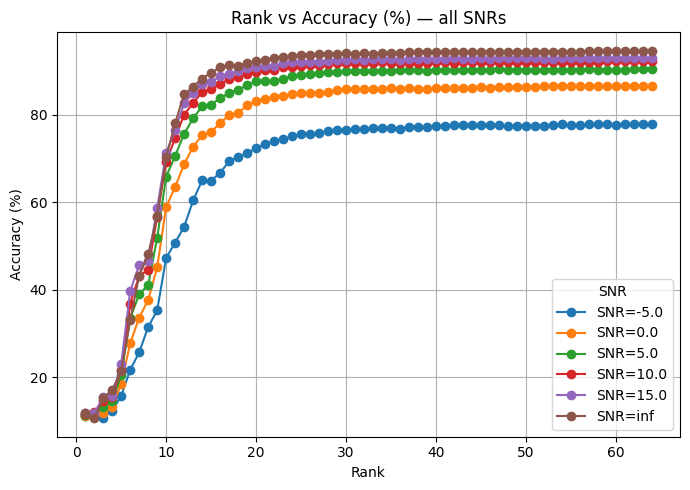


=== Minimum rank to reach acc/max(acc) ≥ 0.90 (acc_non_silence) ===
 snr_eval  min_rank_for_ratio  ratio_target  achieved_ratio_at_min_rank  acc_at_min_rank   max_acc
     -5.0                  18           0.9                    0.901563        70.211730 77.877829
      0.0                  16           0.9                    0.901630        78.072524 86.590411
      5.0                  14           0.9                    0.905762        81.869068 90.386955
     10.0                  14           0.9                    0.922225        85.130202 92.309564
     15.0                  13           0.9                    0.913066        84.862497 92.942322
      inf                  13           0.9                    0.913043        86.371380 94.597226


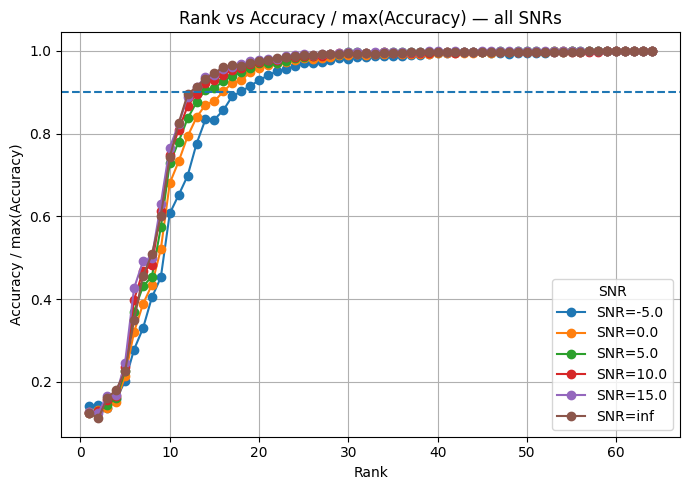

In [59]:
# Normal accuracy plots
summary, ratio_tbl = plot_rank_vs_acc_per_snr(df, include_silence=False, y_mode="acc",plot_per_snr=False)

# Ratio plots + printed table of min rank per SNR to reach 0.8
summary, ratio_tbl = plot_rank_vs_acc_per_snr(
    df,
    include_silence=False,
    y_mode="ratio",
    ratio_target=0.90,
    print_ratio_summary=True,
    plot_per_snr=False,
)

In [63]:
g = (
    comb_1_df
    .assign(is_silence=comb_1_df["label"] == "SILENCE")
    .groupby(["rank", "snr_eval"])
)

acc_all = g["correct"].mean() * 100

acc_non_silence = (
    comb_1_df[comb_1_df["label"] != "SILENCE"]
    .groupby(["rank", "snr_eval"])["correct"]
    .mean()
    * 100
)

summary = (
    pd.concat(
        {
            "acc_all": acc_all,
            "acc_non_silence": acc_non_silence,
        },
        axis=1,
    )
    .assign(acc_diff=lambda df: df["acc_all"] - df["acc_non_silence"])
)

summary

acc_all  acc_non_silence  acc_diff
rank snr_eval                                      
1    -5.0      11.428571        11.048917  0.379654
      0.0      11.450720        11.073254  0.377466
      5.0      11.650055        11.292285  0.357770
      10.0     11.893688        11.559990  0.333697
      15.0     12.181617        11.876369  0.305248
...                  ...              ...       ...
64    0.0      87.685493        86.468727  1.216766
      5.0      91.251384        90.386955  0.864429
      10.0     93.001107        92.309564  0.691543
      15.0     93.554817        92.917985  0.636832
      inf      95.083056        94.597226  0.485831

[384 rows x 3 columns]